In [1]:
from sqlalchemy import create_engine
from snowflake.sqlalchemy import URL
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import shap
import matplotlib.pyplot as plt

c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\snowflake\connector\vendored\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(
c:\Users\knguy139\Documents\Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
engine = create_engine(URL(
    account       = "UHG-UHGDWAAS",
    user          = "KHANG.NGUYEN@UHC.COM",
    authenticator = "externalbrowser",
    role          = "AZU_SDRP_VING_PRD_DEVELOPER_ROLE",
    warehouse     = "VING_PRD_MNR_HCE_DATAINFRA_WH",
    database      = "VING_PRD_TREND_DB",
    schema        = "TMP_1M"
))

In [3]:
df_2025 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202501' and '202512'
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

df_2026 = pd.read_sql("""
    select
        d.collection as hospital_group
        , a.fin_market
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
        , count(distinct case when a.p2p_full_ovtn = 1 then a.case_id end) as p2p_ovrtn_cnt
        , count(distinct case when a.appeal_ovrtn_ind = 1 then a.case_id end) as appeal_ovrtn_cnt
        , count(distinct case when a.mcr_ovtrn_ind = 1 then a.case_id end) as mcr_ovrtn_cnt
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.member_appeal_ind = 1 then a.case_id end) as member_appeal_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202601' and '202604'
    group by 1,2
    having count(distinct a.case_id) >= 30
""", engine)

print(f"2025: {len(df_2025)} rows | 2026: {len(df_2026)} rows")

 pip install snowflake-connector-python[secure-local-storage]


Initiating login request with your identity provider. Press CTRL+C to abort and try again...
Going to open: https://login.microsoftonline.com/db05faca-c82a-4b9d-b9c5-0f64b6755421/saml2?SAMLRequest=lVJdb9owFP0rkfec2AmBFguo%2BBgCrWWsQKXyMjm2AxaOndpO0%2B7XzwkgdQ%2BttAdLln3OPefecwd3b4UMXrmxQqshiCMEAq6oZkIdhmC3nYe3ILCOKEakVnwI3rkFd6OBJYUs8bhyR%2FXIXypuXeALKYubjyGojMKaWGGxIgW32FG8GT%2Fc4yRCmFjLjfNy4EJhVnito3MlhrCu66juRNocYIIQgqgPPaqBfAMfJMqvNUqjnaZaXilvvqdPJGKI0kbCI7zC%2BkKcCHUewVcq2Rlk8WK7XYfrn5stCMbX7qZa2argZsPNq6B893h%2FNmC9g%2Bp4CP1hNSH295FEVuk6l%2BTEqS7Kyvmakb%2FBnDMo9UH4SS1nQ1CeBPul12Q%2FXqSL%2BQ4VT5MXMoun%2ByybPB%2BO2YnH6M9y9T1b9X48n1IKgqdrrkmT69Laii9Vk6bzTyjphagXJt1tfIM7fYySqJOgPQhmPk2hiGuZV8utj6gQ1Girc6eVFIq3LlmGujmhJKS3CQnTrM%2FCrE%2B7Icp7ada76XbTJIZNZgk47w1ujZjR%2F01jAD9yLwu48pksZ2stBX0P5toUxH0eWRzF7YtgYd5CMS%2BIkGPGDLfWRyelrqeGE%2Bf33JmKAzg6q%2F676aO%2F&RelayState=ver%3A3-hint%3A260092117886646-ETMsDgAAAZ7%2F3SAvABRBRVMvQ0JDL1BLQ1M1UGFkZGluZwEAABAAEPtLKaIMU3O4LHXoCX2rBrYAAACQNH6T

In [4]:
# functions kept — each called 2+ times

def mom_optimal_k(successes, trials):
    """MoM estimator for Beta-Binomial k (alpha+beta). Returns (k, p_bar)."""
    mask = (trials > 0) & (successes >= 0)
    s, n = successes[mask].values, trials[mask].values
    p = s / n
    p_bar = p.mean()
    v_obs = p.var(ddof = 1)
    n_bar = len(n) / np.sum(1.0 / n)
    v_sampling = p_bar * (1 - p_bar) / n_bar
    v_signal = v_obs - v_sampling
    if v_signal <= 0:
        return 50.0, p_bar
    alpha_hat = p_bar * (p_bar * (1 - p_bar) / v_signal - 1)
    beta_hat = (1 - p_bar) * (p_bar * (1 - p_bar) / v_signal - 1)
    if alpha_hat <= 0 or beta_hat <= 0:
        return 50.0, p_bar
    return alpha_hat + beta_hat, p_bar


def compute_shrinkage(df, k_map):
    """k_map values are (k, grand_mean) tuples from mom_optimal_k."""
    rate_defs = {
        "initial_adr":     ("initial_adr_cnt",    "case_count"),
        "persistent_adr":  ("persistent_adr_cnt", "case_count"),
        "p2p_overturn":    ("p2p_ovrtn_cnt",      "initial_adr_cnt"),
        "appeal_overturn": ("appeal_ovrtn_cnt",   "initial_adr_cnt"),
        "mcr_overturn":    ("mcr_ovrtn_cnt",      "initial_adr_cnt"),
        "md_review":       ("md_reviewed_cnt",    "case_count"),
    }
    if "member_appeal_cnt" in df.columns:
        rate_defs["member_appeal"] = ("member_appeal_cnt", "initial_adr_cnt")

    df_out = df.query("case_count >= 30 and initial_adr_cnt >= 10").copy()

    for feat, (num, denom) in rate_defs.items():
        k, gr = k_map.get(feat, (50.0, 0.5))
        df_out[f"{feat}_adj_rate"] = (df_out[num] + k * gr) / (df_out[denom] + k)

    df_out = df_out.assign(
        log_case_count = lambda x: np.log1p(x["case_count"]),
        log_initial_adr_cnt = lambda x: np.log1p(x["initial_adr_cnt"]),
    )

    rate_cols = [c for c in df_out.columns if c.endswith("_adj_rate")]
    df_out[rate_cols] = df_out[rate_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

    return df_out

In [5]:
df_all = pd.concat([df_2025, df_2026], ignore_index = True).query("case_count >= 30")
df_25_broad = df_2025.query("case_count >= 30")
df_26_broad = df_2026.query("case_count >= 30")

rate_configs = {
    "initial_adr":     ("initial_adr_cnt",    "case_count"),
    "persistent_adr":  ("persistent_adr_cnt", "case_count"),
    "p2p_overturn":    ("p2p_ovrtn_cnt",      "initial_adr_cnt"),
    "appeal_overturn": ("appeal_ovrtn_cnt",   "initial_adr_cnt"),
    "mcr_overturn":    ("mcr_ovrtn_cnt",      "initial_adr_cnt"),
    "md_review":       ("md_reviewed_cnt",    "case_count"),
}

# pooled k from combined data — returns (k, p_bar) tuples
k_map = {feat: mom_optimal_k(df_all[num], df_all[denom]) for feat, (num, denom) in rate_configs.items()}
k_map["member_appeal"] = mom_optimal_k(
    df_26_broad["member_appeal_cnt"],
    df_26_broad["initial_adr_cnt"]
)

# per-year k for features with >30% divergence: mcr_overturn, appeal_overturn
k_mcr_25 = mom_optimal_k(df_25_broad["mcr_ovrtn_cnt"], df_25_broad["initial_adr_cnt"])
k_mcr_26 = mom_optimal_k(df_26_broad["mcr_ovrtn_cnt"], df_26_broad["initial_adr_cnt"])

k_appeal_25 = mom_optimal_k(df_25_broad["appeal_ovrtn_cnt"], df_25_broad["initial_adr_cnt"])
k_appeal_26 = mom_optimal_k(df_26_broad["appeal_ovrtn_cnt"], df_26_broad["initial_adr_cnt"])

print("k_map (pooled):")
for feat_name, (k_val, gm_val) in k_map.items():
    print(f"  {feat_name:<20}: k = {k_val:.1f}, grand_mean = {gm_val:.4f}")
print(f"\nmcr_overturn per-year: 2025 = {k_mcr_25[0]:.1f}, 2026 = {k_mcr_26[0]:.1f}")
print(f"appeal_overturn per-year: 2025 = {k_appeal_25[0]:.1f}, 2026 = {k_appeal_26[0]:.1f}")

k_map (pooled):
  initial_adr         : k = 8.3, grand_mean = 0.2441
  persistent_adr      : k = 15.1, grand_mean = 0.1299
  p2p_overturn        : k = 8.7, grand_mean = 0.3552
  appeal_overturn     : k = 1.1, grand_mean = 0.0175
  mcr_overturn        : k = 228.8, grand_mean = 0.0230
  md_review           : k = 2.0, grand_mean = 0.5792
  member_appeal       : k = 5.1, grand_mean = 0.0260

mcr_overturn per-year: 2025 = 149.1, 2026 = 50.0
appeal_overturn per-year: 2025 = 1.3, 2026 = 0.7


In [6]:
iso_kpi_8 = [
    "log_case_count", "log_initial_adr_cnt",
    "initial_adr_adj_rate", "persistent_adr_adj_rate", "p2p_overturn_adj_rate",
    "appeal_overturn_adj_rate", "mcr_overturn_adj_rate", "md_review_adj_rate",
]
iso_kpi_9 = iso_kpi_8 + ["member_appeal_adj_rate"]

# per-year k overrides for mcr_overturn and appeal_overturn
k_map_25 = {**k_map, "mcr_overturn": k_mcr_25, "appeal_overturn": k_appeal_25}
k_map_26 = {**k_map, "mcr_overturn": k_mcr_26, "appeal_overturn": k_appeal_26}

df_iso_25 = compute_shrinkage(df_2025.copy(), k_map_25)
df_iso_26 = compute_shrinkage(df_2026.copy(), k_map_26)

print(f"IF-ready: 2025 = {len(df_iso_25)} rows (8 feat) | 2026 = {len(df_iso_26)} rows (9 feat)")

IF-ready: 2025 = 1226 rows (8 feat) | 2026 = 790 rows (9 feat)


In [7]:
N_BOOT = 200
BOOT_THRESHOLD_PCT = 2.5
CONSENSUS_THRESHOLD = 0.50  # majority vote — calibrated via unimodal bootstrap distribution


def bootstrap_if(X, n_boot = N_BOOT, percentile = BOOT_THRESHOLD_PCT):
    n = len(X)
    flag_counts = np.zeros(n)
    for b in range(n_boot):
        idx = np.random.choice(n, size = n, replace = True)
        X_boot = X[idx]
        model = IsolationForest(contamination = "auto", n_estimators = 300, random_state = b)
        model.fit(X_boot)
        scores = model.decision_function(X)
        threshold = np.percentile(scores, percentile)
        flag_counts += (scores < threshold).astype(int)
    return flag_counts / n_boot


np.random.seed(42)

print("Running 200x bootstrap for 2025 (8 feat)...")
df_iso_25["bootstrap_flag_pct"] = bootstrap_if(df_iso_25[iso_kpi_8].values)

print("Running 200x bootstrap for 2026 (9 feat)...")
df_iso_26["bootstrap_flag_pct"] = bootstrap_if(df_iso_26[iso_kpi_9].values)

df_iso_25 = df_iso_25.assign(flagged = lambda x: x["bootstrap_flag_pct"] >= CONSENSUS_THRESHOLD)
df_iso_26 = df_iso_26.assign(flagged = lambda x: x["bootstrap_flag_pct"] >= CONSENSUS_THRESHOLD)

print(f"\n2025 flagged: {df_iso_25['flagged'].sum()} / {len(df_iso_25)}")
print(f"2026 flagged: {df_iso_26['flagged'].sum()} / {len(df_iso_26)}")
print(f"\nConsensus threshold: {CONSENSUS_THRESHOLD} (majority vote)")

Running 200x bootstrap for 2025 (8 feat)...
Running 200x bootstrap for 2026 (9 feat)...

2025 flagged: 32 / 1226
2026 flagged: 19 / 790

Consensus threshold: 0.5 (majority vote)


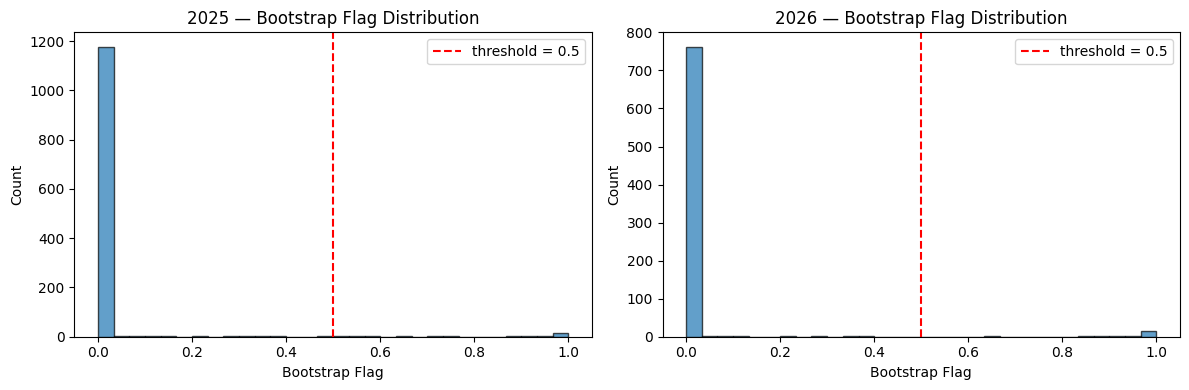

In [21]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

for ax, df_yr, yr in [(axes[0], df_iso_25, "2025"), (axes[1], df_iso_26, "2026")]:
    ax.hist(df_yr["bootstrap_flag_pct"], bins = 30, edgecolor = "black", alpha = 0.7)
    ax.axvline(CONSENSUS_THRESHOLD, color = "red", linestyle = "--", label = f"threshold = {CONSENSUS_THRESHOLD}")
    ax.set_xlabel("Bootstrap Flag")
    ax.set_ylabel("Count")
    ax.set_title(f"{yr} — Bootstrap Flag Distribution")
    ax.legend()

plt.tight_layout()
plt.show()

In [8]:
def compute_shap(df, features):
    X = df[features].values
    model = IsolationForest(contamination = "auto", n_estimators = 300, random_state = 42)
    model.fit(X)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    df_shap = pd.DataFrame(shap_values, columns = features, index = df.index)
    df = df.assign(
        shap_driver = df_shap.apply(lambda row: row.idxmin(), axis = 1),
        shap_driver_value = df_shap.apply(lambda row: row.min(), axis = 1),
    )

    for feat in features:
        median_val = df[feat].median()
        df.loc[df["shap_driver"] == feat, "driver_direction"] = np.where(
            df.loc[df["shap_driver"] == feat, feat] > median_val, "HIGH", "LOW"
        )
    return df, shap_values, explainer


df_iso_25, shap_25, explainer_25 = compute_shap(df_iso_25, iso_kpi_8)
df_iso_26, shap_26, explainer_26 = compute_shap(df_iso_26, iso_kpi_9)

print("SHAP computed for both years.")

SHAP computed for both years.


C:\Users\knguy139\AppData\Local\Temp\ipykernel_34724\2105257128.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_25, df_iso_25[iso_kpi_8].values, feature_names = iso_kpi_8, show = False, plot_type = "bar")
C:\Users\knguy139\AppData\Local\Temp\ipykernel_34724\2105257128.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_26, df_iso_26[iso_kpi_9].values, feature_names = iso_kpi_9, show = False, plot_type = "bar")


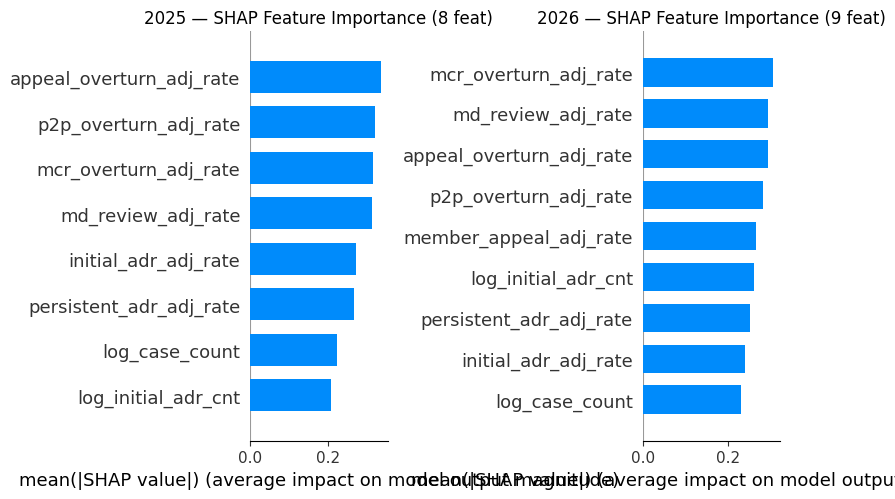

In [9]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

plt.sca(axes[0])
shap.summary_plot(shap_25, df_iso_25[iso_kpi_8].values, feature_names = iso_kpi_8, show = False, plot_type = "bar")
axes[0].set_title("2025 — SHAP Feature Importance (8 feat)")

plt.sca(axes[1])
shap.summary_plot(shap_26, df_iso_26[iso_kpi_9].values, feature_names = iso_kpi_9, show = False, plot_type = "bar")
axes[1].set_title("2026 — SHAP Feature Importance (9 feat)")

plt.tight_layout()
plt.show()

In [10]:
DRIVER_RENAME = {
    'md_review_adj_rate': 'md_escalation_rate',
    'member_appeal_adj_rate': 'member_appeal_rate',
    'persistent_adr_adj_rate': 'persistent_adr_rate',
    'initial_adr_adj_rate': 'initial_adr_rate',
}
KEEP_DRIVERS = set(DRIVER_RENAME.keys())

def build_output_table(df, year_label, features):
    df = df.copy()
    median_vals = df[features].median()
    df['driver_median'] = df['shap_driver'].map(lambda d: median_vals.get(d, np.nan))
    df['driver_actual'] = df.apply(lambda row: row.get(row['shap_driver'], np.nan), axis=1)

    out = df.query('flagged').copy()
    out = out[out['shap_driver'].isin(KEEP_DRIVERS)]
    out = out.sort_values('case_count', ascending=False)

    out['shap_driver'] = out['shap_driver'].map(DRIVER_RENAME)
    out['driver_actual_fmt'] = (out['driver_actual'] * 100).round(1).astype(str) + '%'
    out['driver_median_fmt'] = (out['driver_median'] * 100).round(1).astype(str) + '%'
    out['bootstrap_flag_pct'] = (out['bootstrap_flag_pct'] * 100).round(1)

    out = out[[
        'hospital_group', 'fin_market', 'case_count',
        'bootstrap_flag_pct', 'shap_driver',
        'driver_direction', 'driver_actual_fmt', 'driver_median_fmt'
    ]].copy()
    out.columns = ['Hospital Group', 'Market', 'Cases',
                   'Bootstrap %', 'SHAP Driver',
                   'Direction', 'Driver Value', 'Median']
    print(f"\n{'='*80}")
    print(f" {year_label} — FLAGGED HOSPITALS (sorted by case count desc)")
    print(f"{'='*80}")
    print(out.to_string(index=False))
    return out

table_25 = build_output_table(df_iso_25, '2025', iso_kpi_8)
table_26 = build_output_table(df_iso_26, '2026', iso_kpi_9)


 2025 — FLAGGED HOSPITALS (sorted by case count desc)
                          Hospital Group Market  Cases  Bootstrap %         SHAP Driver Direction Driver Value Median
          ADVOCATE HEALTH & HOSPITALS IL     IL   7393        100.0  md_escalation_rate       LOW         2.3%  70.1%
                                 Steward     FL   2709        100.0 persistent_adr_rate      HIGH        38.9%  14.8%
                             MAYO CLINIC     MN   1695        100.0  md_escalation_rate       LOW         5.8%  70.1%
                            Ascension MI     MI   1330        100.0  md_escalation_rate       LOW        11.6%  70.1%
HEALTH CARE AUTHORITY OF THE CITY OF ANN     AL    860        100.0  md_escalation_rate       LOW         6.4%  70.1%
        ADVOCATE NORTHSIDE HEALTH SYSTEM     IL    721         99.5  md_escalation_rate       LOW         3.1%  70.1%
                        Mosaic Life Care     MO    465         68.0  md_escalation_rate       LOW         8.6%  70.1%
 

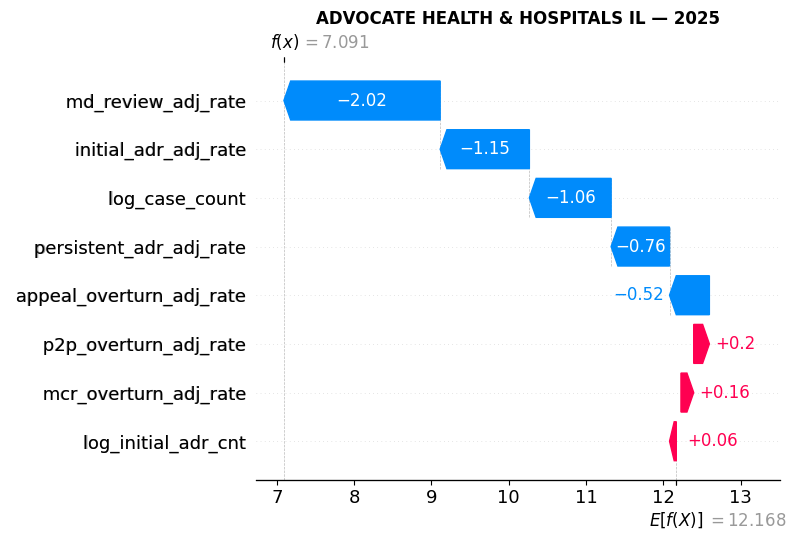

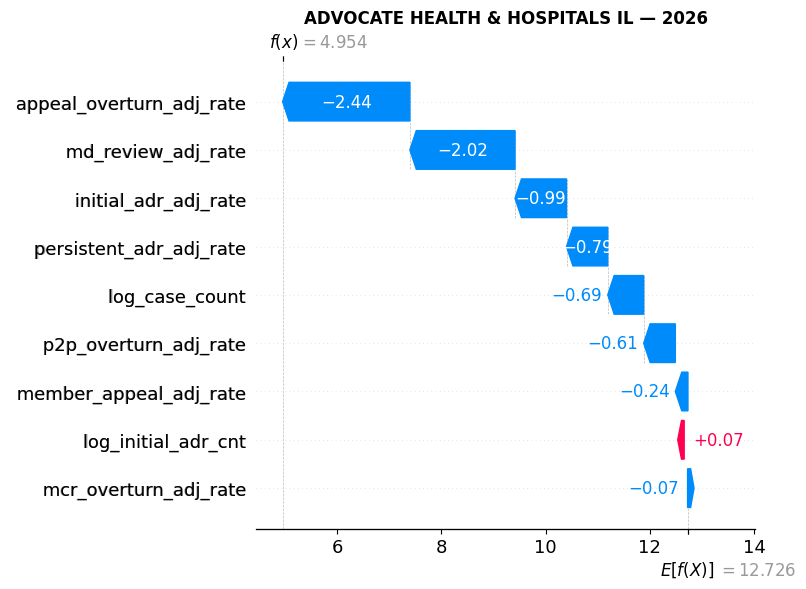

In [11]:
TARGET_HOSPITAL = 'ADVOCATE HEALTH & HOSPITALS IL'

def plot_waterfall(df, features, explainer, hospital, year_label):
    explanation = explainer(df[features].values)
    explanation.feature_names = features

    mask = df['hospital_group'] == hospital
    if not mask.any():
        print(f"{hospital} not found in {year_label}")
        return

    pos = np.where(mask.values)[0][0]
    shap.plots.waterfall(explanation[pos], max_display=11, show=False)
    ax = plt.gca()

    clean_labels = []
    for lbl in ax.get_yticklabels():
        raw = lbl.get_text()
        if ' = ' in raw:
            clean_labels.append(raw.split(' = ')[1].strip())
        else:
            clean_labels.append(raw)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(clean_labels)

    for patch in ax.patches:
        fc = patch.get_facecolor()
        if fc[2] > fc[0]:
            patch.set_facecolor('#002677')

    plt.title(f"{hospital} \u2014 {year_label}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_waterfall(df_iso_25, iso_kpi_8, explainer_25, TARGET_HOSPITAL, '2025')
plot_waterfall(df_iso_26, iso_kpi_9, explainer_26, TARGET_HOSPITAL, '2026')

In [12]:
# Monthly rates for flagged hospitals (md_escalation, initial_adr, persistent_adr)
flagged_25 = df_iso_25.query('flagged')[['hospital_group', 'fin_market', 'shap_driver', 'bootstrap_flag_pct']].copy()
flagged_25['shap_driver'] = flagged_25['shap_driver'].map(DRIVER_RENAME).fillna(flagged_25['shap_driver'])
flagged_25['top_shap_driver'] = flagged_25['shap_driver'] + ' (2025)'
flagged_25['bootstrap_flag_pct_25'] = flagged_25['bootstrap_flag_pct']
flagged_25 = flagged_25[['hospital_group', 'fin_market', 'top_shap_driver', 'bootstrap_flag_pct_25']]

flagged_26 = df_iso_26.query('flagged')[['hospital_group', 'fin_market', 'shap_driver', 'bootstrap_flag_pct']].copy()
flagged_26['shap_driver'] = flagged_26['shap_driver'].map(DRIVER_RENAME).fillna(flagged_26['shap_driver'])
flagged_26['top_shap_driver_26'] = flagged_26['shap_driver'] + ' (2026)'
flagged_26['bootstrap_flag_pct_26'] = flagged_26['bootstrap_flag_pct']
flagged_26 = flagged_26[['hospital_group', 'fin_market', 'top_shap_driver_26', 'bootstrap_flag_pct_26']]

# Build lookup at hospital_group x fin_market — one row per combo, both years' info
flagged_lookup = flagged_25.merge(flagged_26, on=['hospital_group', 'fin_market'], how='outer')

# Combine driver labels (handle NaN from outer join)
flagged_lookup['top_shap_driver'] = flagged_lookup.apply(
    lambda r: ', '.join([v for v in [r.get('top_shap_driver'), r.get('top_shap_driver_26')] if pd.notna(v)]), axis=1
)
flagged_lookup['bootstrap_flag_pct'] = flagged_lookup.apply(
    lambda r: ', '.join([f"{v:.1%}" for v in [r.get('bootstrap_flag_pct_25'), r.get('bootstrap_flag_pct_26')] if pd.notna(v)]), axis=1
)
flagged_lookup = flagged_lookup[['hospital_group', 'fin_market', 'top_shap_driver', 'bootstrap_flag_pct']]
flagged_lookup = flagged_lookup[~flagged_lookup['top_shap_driver'].str.contains('member_appeal_rate')]
flagged_hospitals = set(flagged_lookup['hospital_group'])

df_monthly = pd.read_sql(f"""
    select
        d.collection as hospital_group
        , a.fin_market
        , a.hce_admit_month
        , count(distinct a.case_id) as case_count
        , count(distinct case when a.icm_md_reviewed_ind = 1 then a.case_id end) as md_reviewed_cnt
        , count(distinct case when a.initialfulladr_cases = 1 then a.case_id end) as initial_adr_cnt
        , count(distinct case when a.persistentfulladr_cases = 1 then a.case_id end) as persistent_adr_cnt
    from tmp_1m.ec_avtar_25_26_3_od as a
    left join tmp_1y.tin_collection as d
        on substr(a.fa_prov_id, 2, 9) = d.tin
    where fin_brand = 'M&R'
        and (
            (ip_type in ('Medical', 'Surgical', 'Transplant')
             and to_varchar(admit_dt_act, 'MM/dd/yyyy') is not null)
            or ip_type in ('LTAC', 'SNF', 'AIR')
        )
        and loc_flag = 1
        and (
            (global_cap = 'NA' and sgr_source_name = 'COSMOS'
             and fin_product_level_3 != 'INSTITUTIONAL' and tfm_include_flag = 1)
            or (sgr_source_name = 'NICE' and nce_tadm_dec_risk_type in ('FFS', 'PHYSICIAN'))
        )
        and d.collection is not null
        and hce_admit_month between '202501' and '202604'
    group by 1, 2, 3
""", engine)

df_monthly = df_monthly[df_monthly['hospital_group'].isin(flagged_hospitals)].copy()

df_monthly['md_escalation_rate'] = df_monthly['md_reviewed_cnt'] / df_monthly['case_count']
df_monthly['initial_adr_rate'] = df_monthly['initial_adr_cnt'] / df_monthly['case_count']
df_monthly['persistent_adr_rate'] = df_monthly['persistent_adr_cnt'] / df_monthly['case_count']

df_monthly = df_monthly.merge(flagged_lookup, on=['hospital_group', 'fin_market'], how='inner')

total_cases = df_monthly.groupby('hospital_group')['case_count'].sum().rename('total_cases')
df_monthly = df_monthly.merge(total_cases, on='hospital_group')
df_monthly = df_monthly.sort_values(['total_cases', 'hospital_group', 'hce_admit_month'], ascending=[False, True, True])
df_monthly['hce_admit_year'] = df_monthly['hce_admit_month'].str[:4]

df_monthly_out = df_monthly[[
    'hospital_group', 'fin_market', 'top_shap_driver', 'bootstrap_flag_pct',
    'hce_admit_year', 'hce_admit_month', 'case_count',
    'md_escalation_rate', 'initial_adr_rate', 'persistent_adr_rate'
]].copy()

print(f"Flagged hospitals: {len(flagged_hospitals)} | Monthly rows: {len(df_monthly_out)}")
df_monthly_out

Flagged hospitals: 38 | Monthly rows: 600


,hospital_group,fin_market,top_shap_driver,bootstrap_flag_pct,hce_admit_year,hce_admit_month,case_count,md_escalation_rate,initial_adr_rate,persistent_adr_rate
202,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202501,1543,0.620868,0.425794,0.227479
553,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202502,1431,0.586303,0.439553,0.240391
459,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202503,1411,0.608079,0.438696,0.237420
489,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202504,1325,0.651321,0.443019,0.244528
223,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202505,1419,0.644820,0.422128,0.248062
...,...,...,...,...,...,...,...,...,...,...
317,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2025,202511,1,1.000000,0.000000,0.000000
138,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2025,202512,3,0.666667,0.000000,0.000000
330,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2026,202601,1,1.000000,0.000000,0.000000
139,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2026,202602,1,1.000000,0.000000,0.000000


In [13]:
df_monthly_out.to_csv(r"C:\Users\knguy139\Documents\Projects\Data\Output\LOC_IF_output_v3.csv", index = False)

In [14]:
df_monthly_out

,hospital_group,fin_market,top_shap_driver,bootstrap_flag_pct,hce_admit_year,hce_admit_month,case_count,md_escalation_rate,initial_adr_rate,persistent_adr_rate
202,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202501,1543,0.620868,0.425794,0.227479
553,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202502,1431,0.586303,0.439553,0.240391
459,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202503,1411,0.608079,0.438696,0.237420
489,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202504,1325,0.651321,0.443019,0.244528
223,Adventist Health System Florida,FL,log_initial_adr_cnt (2025),76.5%,2025,202505,1419,0.644820,0.422128,0.248062
...,...,...,...,...,...,...,...,...,...,...
317,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2025,202511,1,1.000000,0.000000,0.000000
138,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2025,202512,3,0.666667,0.000000,0.000000
330,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2026,202601,1,1.000000,0.000000,0.000000
139,ATLANTICARE REG MED CTR,PA,appeal_overturn_adj_rate (2025),99.0%,2026,202602,1,1.000000,0.000000,0.000000
